### Author
Name: Zhihao Cui
Institute: School of Mathematics and Statistics
NO: 20233002662

分类问题，脊椎动物数据
本实验通过脊椎动物数据集演示分类模型的基本流程，并扩展到合成数据集上比较多种分类器的性能

In [1]:
import pandas as pd
import numpy as np
from sklearn import tree
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import ensemble
from sklearn.tree import DecisionTreeClassifier

import warnings
warnings.filterwarnings("ignore")  # 忽略所有警告

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\ensemble\weight_boosting.py:29: DeprecationWarning: numpy.core.umath_tests is an internal NumPy module and should not be imported. It will be removed in a future NumPy release.
  from numpy.core.umath_tests import inner1d


In [2]:
# 读取脊椎动物数据集，header='infer'表示自动将第一行作为列名
data = pd.read_csv('vertebrate.csv', header='infer')
print(data)

             Name  Warm-blooded  Gives Birth  Aquatic Creature  \
0           human             1            1                 0   
1          python             0            0                 0   
2          salmon             0            0                 1   
3           whale             1            1                 1   
4            frog             0            0                 1   
5          komodo             0            0                 0   
6             bat             1            1                 0   
7          pigeon             1            0                 0   
8             cat             1            1                 0   
9   leopard shark             0            1                 1   
10         turtle             0            0                 1   
11        penguin             1            0                 1   
12      porcupine             1            1                 0   
13            eel             0            0                 1   
14     sal

In [3]:
# 将除哺乳动物外的其他类别统一标记为 'non-mammals'，进行二分类任务
data['Class'] = data['Class'].replace(
    ['fishes', 'birds', 'amphibians', 'reptiles'],
    'non-mammals'
)
print(data)

             Name  Warm-blooded  Gives Birth  Aquatic Creature  \
0           human             1            1                 0   
1          python             0            0                 0   
2          salmon             0            0                 1   
3           whale             1            1                 1   
4            frog             0            0                 1   
5          komodo             0            0                 0   
6             bat             1            1                 0   
7          pigeon             1            0                 0   
8             cat             1            1                 0   
9   leopard shark             0            1                 1   
10         turtle             0            0                 1   
11        penguin             1            0                 1   
12      porcupine             1            1                 0   
13            eel             0            0                 1   
14     sal

决策树分类器
在本节中，我们将决策树分类器应用于上一小节中描述的脊椎动物数据集

In [4]:
# 准备特征矩阵 X 和目标向量 Y
Y = data['Class']
X = data.drop(['Name', 'Class'], axis=1)

In [5]:
# 初始化决策树分类器：使用熵作为分裂准则，最大深度设为3，随机种子固定保证可复现
clf = tree.DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=1)
clf = clf.fit(X, Y)

这一部分省略了绘图，这里手动输出

In [6]:
def print_decision_tree(tree, feature_names, class_names, node_id=0, depth=0):
    """
    递归打印决策树的结构（文本版）
    """
    # 获取当前节点的信息
    left_child = tree.children_left[node_id]
    right_child = tree.children_right[node_id]
    threshold = tree.threshold[node_id]
    feature = tree.feature[node_id]
    value = tree.value[node_id]  # 形状 (1, n_classes)
    samples = tree.n_node_samples[node_id]
    impurity = tree.impurity[node_id]

    indent = "  " * depth

    if left_child == -1:  # 叶子节点
        class_idx = value.argmax()
        class_name = class_names[class_idx]
        print(f"{indent}|--- 叶子节点: 类别={class_name}, 样本数={samples}, 值={value}")
    else:
        feature_name = feature_names[feature]
        print(f"{indent}|--- 分裂: {feature_name} <= {threshold:.3f} (不纯度={impurity:.3f}, 样本数={samples})")
        # 递归左子树（True分支）
        print_decision_tree(tree, feature_names, class_names, left_child, depth+1)
        # 递归右子树（False分支）
        print_decision_tree(tree, feature_names, class_names, right_child, depth+1)

# 使用方法
print_decision_tree(clf.tree_, feature_names=X.columns, class_names=['mammals', 'non-mammals'])

|--- 分裂: Gives Birth <= 0.500 (不纯度=0.918, 样本数=15)
  |--- 叶子节点: 类别=non-mammals, 样本数=9, 值=[[0. 9.]]
  |--- 分裂: Warm-blooded <= 0.500 (不纯度=0.650, 样本数=6)
    |--- 叶子节点: 类别=non-mammals, 样本数=1, 值=[[0. 1.]]
    |--- 叶子节点: 类别=mammals, 样本数=5, 值=[[5. 0.]]


In [7]:
# 构造测试数据，包含4个新样本，用于评估模型的泛化能力
testData = [
    ['美国毒蜥', 0, 0, 0, 0, 1, 1, 'non-mammals'],
    ['鸭嘴兽',   1, 0, 0, 0, 1, 1, 'mammals'],
    ['猫头鹰',   1, 0, 0, 1, 1, 0, 'non-mammals'],
    ['海豚',     1, 1, 1, 0, 0, 0, 'mammals']
]
# 将列表转换为DataFrame，并沿用原数据的列名
testData = pd.DataFrame(testData, columns=data.columns)
print(testData)

   Name  Warm-blooded  Gives Birth  Aquatic Creature  Aerial Creature  \
0  美国毒蜥             0            0                 0                0   
1   鸭嘴兽             1            0                 0                0   
2   猫头鹰             1            0                 0                1   
3    海豚             1            1                 1                0   

   Has Legs  Hibernates        Class  
0         1           1  non-mammals  
1         1           1      mammals  
2         1           0  non-mammals  
3         0           0      mammals  


In [8]:
# 准备测试集的特征和真实标签
testY = testData['Class']
testX = testData.drop(['Name', 'Class'], axis=1)

In [9]:
# 使用训练好的决策树进行预测
predY = clf.predict(testX)
# 将预测结果与样本名称合并显示
predictions = pd.concat(
    [testData['Name'], pd.Series(predY, name='Predicted Class')],
    axis=1
)
print(predictions)

   Name Predicted Class
0  美国毒蜥     non-mammals
1   鸭嘴兽     non-mammals
2   猫头鹰     non-mammals
3    海豚         mammals


In [10]:
print('Accuracy on test data is %.2f' % accuracy_score(testY, predY))

Accuracy on test data is 0.75


模型过拟合
这一部分展现模型的过拟合现象，通过合成二维数据并调节决策树最大深度来观察训练集与测试集精度差异

Text(0.5,1,'Synthetic 2D Classification Data')

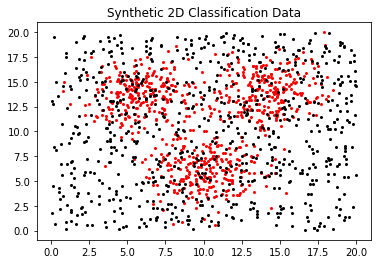

In [19]:
N = 1500
mean1 = [6, 14]
mean2 = [10, 6]
mean3 = [14, 14]
cov = [[3.5, 0], [0, 3.5]]  # 对角协方差

np.random.seed(50)
X = np.random.multivariate_normal(mean1, cov, int(N / 6))
X = np.concatenate((X, np.random.multivariate_normal(mean2, cov, int(N / 6))))
X = np.concatenate((X, np.random.multivariate_normal(mean3, cov, int(N / 6))))
X = np.concatenate((X, 20 * np.random.rand(int(N / 2), 2)))    # 添加随机噪声点
Y = np.concatenate((np.ones(int(N / 2)), np.zeros(int(N / 2))))    # 前一半为类别1，后一半为类别0

# 绘制合成数据的散点图，红色 '+' 表示类别1，黑色 '.' 表示类别0
plt.figure()
plt.plot(X[:int(N / 2), 0], X[:int(N / 2), 1], 'r.',
         X[int(N / 2):, 0], X[int(N / 2):, 1], 'k.', ms=4)
plt.title('Synthetic 2D Classification Data')

In [12]:
# 将数据集划分为训练集（80%）和测试集（20%）
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1)

模型拟合与评估

In [13]:
# 尝试一系列不同的最大深度值
maxdepths = [2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 35, 40, 45, 50]
trainAcc = np.zeros(len(maxdepths))    # 存储训练精度
testAcc = np.zeros(len(maxdepths))     # 存储测试精度

index = 0
for depth in maxdepths:
    clf = tree.DecisionTreeClassifier(max_depth=depth, random_state=1)
    clf = clf.fit(X_train, Y_train)
    Y_predTrain = clf.predict(X_train)
    Y_predTest = clf.predict(X_test)
    trainAcc[index] = accuracy_score(Y_train, Y_predTrain)
    testAcc[index] = accuracy_score(Y_test, Y_predTest)
    index += 1

训练和测试精度图

Text(0.5,1,'Decision Tree: Training vs Test Accuracy')

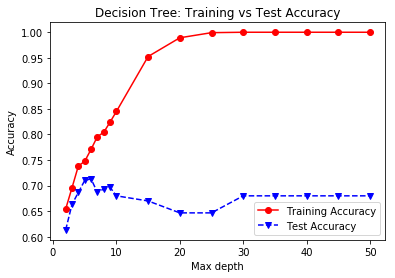

In [14]:
# 绘制不同深度下训练精度和测试精度的变化曲线
plt.figure()
plt.plot(maxdepths, trainAcc, 'ro-', maxdepths, testAcc, 'bv--')
plt.legend(['Training Accuracy', 'Test Accuracy'])
plt.xlabel('Max depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree: Training vs Test Accuracy')

替代分类技术

K紧邻方法

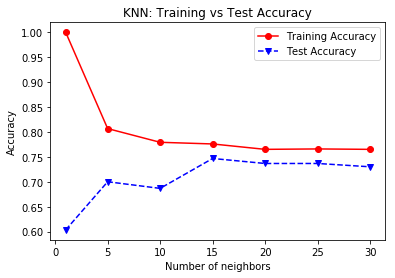

In [15]:
numNeighbors = [1, 5, 10, 15, 20, 25, 30]    # 尝试不同的邻居数量
trainAcc = []
testAcc = []

for k in numNeighbors:
    clf = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)    # 欧氏距离
    clf.fit(X_train, Y_train)
    Y_predTrain = clf.predict(X_train)
    Y_predTest = clf.predict(X_test)
    trainAcc.append(accuracy_score(Y_train, Y_predTrain))
    testAcc.append(accuracy_score(Y_test, Y_predTest))

plt.figure()
plt.plot(numNeighbors, trainAcc, 'ro-', numNeighbors, testAcc, 'bv--')
plt.legend(['Training Accuracy', 'Test Accuracy'])
plt.xlabel('Number of neighbors')
plt.ylabel('Accuracy')
plt.title('KNN: Training vs Test Accuracy')
plt.show()

线性分类器

Text(0.5,1,'Linear SVM')

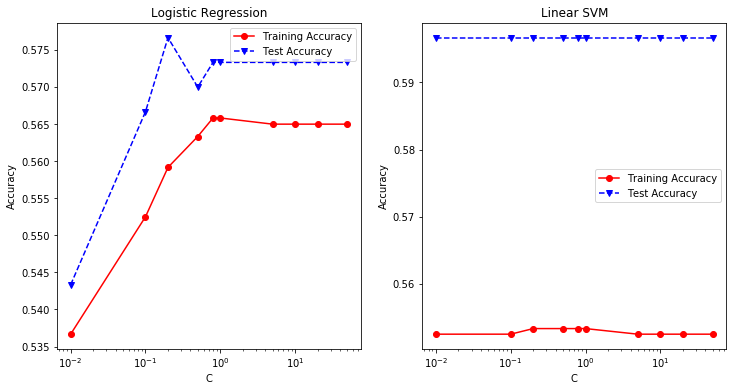

In [16]:
from sklearn import linear_model
from sklearn.svm import SVC

C = [0.01, 0.1, 0.2, 0.5, 0.8, 1, 5, 10, 20, 50]    # 正则化强度的候选值
LRtrainAcc = []
LRtestAcc = []
SVMtrainAcc = []
SVMtestAcc = []

for param in C:
    # 逻辑回归（线性分类器）
    clf = linear_model.LogisticRegression(C=param, max_iter=1000)
    clf.fit(X_train, Y_train)
    Y_predTrain = clf.predict(X_train)
    Y_predTest = clf.predict(X_test)
    LRtrainAcc.append(accuracy_score(Y_train, Y_predTrain))
    LRtestAcc.append(accuracy_score(Y_test, Y_predTest))
    
    # 线性支持向量机
    clf = SVC(C=param, kernel='linear')
    clf.fit(X_train, Y_train)
    Y_predTrain = clf.predict(X_train)
    Y_predTest = clf.predict(X_test)
    SVMtrainAcc.append(accuracy_score(Y_train, Y_predTrain))
    SVMtestAcc.append(accuracy_score(Y_test, Y_predTest))

# 并排绘制逻辑回归和线性SVM的精度变化图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.plot(C, LRtrainAcc, 'ro-', C, LRtestAcc, 'bv--')
ax1.legend(['Training Accuracy', 'Test Accuracy'])
ax1.set_xlabel('C')
ax1.set_xscale('log')
ax1.set_ylabel('Accuracy')
ax1.set_title('Logistic Regression')

ax2.plot(C, SVMtrainAcc, 'ro-', C, SVMtestAcc, 'bv--')
ax2.legend(['Training Accuracy', 'Test Accuracy'])
ax2.set_xlabel('C')
ax2.set_xscale('log')
ax2.set_ylabel('Accuracy')
ax2.set_title('Linear SVM')

非线性支持向量机

Text(0.5,1,'Nonlinear SVM (RBF Kernel)')

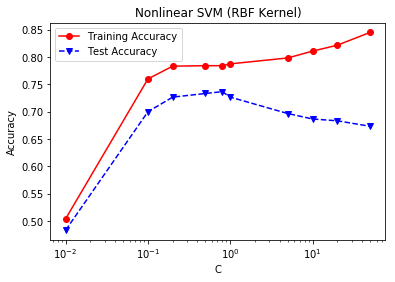

In [17]:
C = [0.01, 0.1, 0.2, 0.5, 0.8, 1, 5, 10, 20, 50]
SVMtrainAcc = []
SVMtestAcc = []

for param in C:
    # 使用 RBF 核的非线性 SVM
    clf = SVC(C=param, kernel='rbf', gamma='auto')
    clf.fit(X_train, Y_train)
    Y_predTrain = clf.predict(X_train)
    Y_predTest = clf.predict(X_test)
    SVMtrainAcc.append(accuracy_score(Y_train, Y_predTrain))
    SVMtestAcc.append(accuracy_score(Y_test, Y_predTest))

plt.figure()
plt.plot(C, SVMtrainAcc, 'ro-', C, SVMtestAcc, 'bv--')
plt.legend(['Training Accuracy', 'Test Accuracy'])
plt.xlabel('C')
plt.xscale('log')
plt.ylabel('Accuracy')
plt.title('Nonlinear SVM (RBF Kernel)')

集成方法
比较随机森林、Bagging 和 AdaBoost 在相同数据集上的表现

Text(0,0.5,'Accuracy')

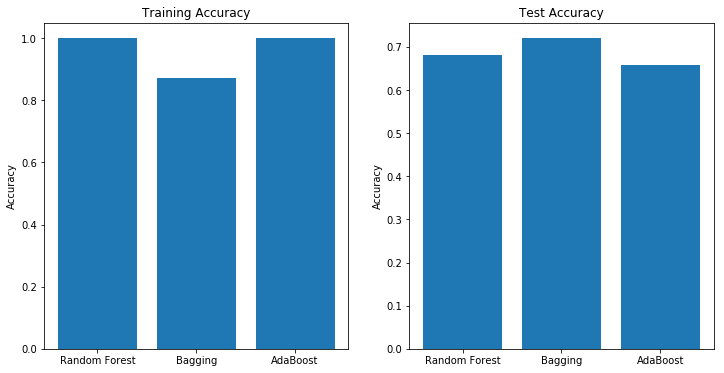

In [18]:
numBaseClassifiers = 500    # 基分类器数量
maxdepth = 10     # 决策树的最大深度（用于 Bagging 和 AdaBoost 的基学习器）
trainAcc = []
testAcc = []

clf = ensemble.RandomForestClassifier(
    n_estimators=numBaseClassifiers,
    random_state=1
)
clf.fit(X_train, Y_train)
Y_predTrain = clf.predict(X_train)
Y_predTest = clf.predict(X_test)
trainAcc.append(accuracy_score(Y_train, Y_predTrain))
testAcc.append(accuracy_score(Y_test, Y_predTest))

# Bagging 集成（基学习器为决策树）
clf = ensemble.BaggingClassifier(
    base_estimator=DecisionTreeClassifier(max_depth=maxdepth, random_state=1),
    n_estimators=numBaseClassifiers,
    random_state=1
)
clf.fit(X_train, Y_train)
Y_predTrain = clf.predict(X_train)
Y_predTest = clf.predict(X_test)
trainAcc.append(accuracy_score(Y_train, Y_predTrain))
testAcc.append(accuracy_score(Y_test, Y_predTest))

# AdaBoost 集成（基学习器同样为决策树）
clf = ensemble.AdaBoostClassifier(
    base_estimator=DecisionTreeClassifier(max_depth=maxdepth, random_state=1),
    n_estimators=numBaseClassifiers,
    random_state=1
)
clf.fit(X_train, Y_train)
Y_predTrain = clf.predict(X_train)
Y_predTest = clf.predict(X_test)
trainAcc.append(accuracy_score(Y_train, Y_predTrain))
testAcc.append(accuracy_score(Y_test, Y_predTest))

# 用柱状图展示三种集成方法的训练精度和测试精度
methods = ['Random Forest', 'Bagging', 'AdaBoost']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.bar([1.5, 2.5, 3.5], trainAcc)
ax1.set_xticks([1.5, 2.5, 3.5])
ax1.set_xticklabels(methods)
ax1.set_title('Training Accuracy')
ax1.set_ylabel('Accuracy')

ax2.bar([1.5, 2.5, 3.5], testAcc)
ax2.set_xticks([1.5, 2.5, 3.5])
ax2.set_xticklabels(methods)
ax2.set_title('Test Accuracy')
ax2.set_ylabel('Accuracy')